# Module: Point Statistics

We can check whether transcripts are distributed equally within the cell, or if they are shifted towards the membrance, which can be due to spillover from adjacent cells.

<center>
 <img src='../_static/img/docs/point_statistics.png' width='50%' />
</center>

This functionality is provided in the `point statistics` (`ps`) module. The idea of this module is to provide an intuition whether transcripts are distributed unequally, meaning they are more likely to have resulted from a spillover from neighbouring cells. This can happen due to imperfect boundaries, dense packing, partial overlaps, and other sources of “spillover” between adjacent cells.

The `ps` module summarizes transcript localization relative to cell (and optionally nucleus) geometry, providing intuitive signals for potential contamination or biased spatial distributions. Metrics can be returned as a table and, if desired, stored in place in the `SpatialData` object.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

In [1]:
%load_ext autoreload
%autoreload 2

## Load data into SegTraQ and run label transfer

In [2]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa

import segtraq

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:533: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you wa

In [3]:
data_path = Path("/g/huber/projects/CODEX/segtraq/data/20260113_Janesick_Replicate1/xenium")

We load [previously built](./io.ipynb) `SpatialData` objects from 10x Genomics Xenium data segmented with Xenium's multimodal cell segmentation (`sdata_xenium`), with Proseg v2.0.5 (`sdata_proseg2`) and Proseg v3.1.0 (`sdata_proseg3`).

In [4]:
sdata_xenium = sd.read_zarr(data_path / "sdata_xenium_crop.zarr")
sdata_proseg2 = sd.read_zarr(data_path / "proseg_output_v2/sdata_proseg_crop.zarr")

We initialize `SegTraQ` objects. 

In [5]:
st_xenium = segtraq.SegTraQ(
    sdata_xenium,
    tables_centroid_x_key=None,
    tables_centroid_y_key=None,
    points_background_id=-1,  # "UNASSIGNED" for Xenium prime
)

st_proseg2 = segtraq.SegTraQ(
    sdata_proseg2,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_key="volume",
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:131: RuntimeWarning: No centroids specified for tables. Centroids will be automatically computed from shapes.
  validate_spatialdata(


For easier access, we store the `SpatialData` object into a dictionary.

In [6]:
st_dict = {"xenium": st_xenium, "proseg2": st_proseg2}

Finally, we filter out transcripts bound by control probes and those with a qv < 20. 

In [7]:
for _method, st in st_dict.items():
    st.filter_control_and_low_quality_transcripts()

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:852: RuntimeWarning: Some of the filtered genes (313) also appear in the tables. These genes are: ['CCL8', 'DNAAF1', 'ITGAX', 'KLRD1', 'FASN']... If you wish to recompute the expression matrix after filtering, set recompute_expression=True.
  _filter_control_and_low_quality_transcripts(


We can then transfer labels from a reference scRNA-seq dataset. 

In [8]:
adata_ref = ad.read_h5ad("../../data/BC_scRNAseq_Janesick.h5ad")

for _method, st in st_dict.items():
    st.run_label_transfer(
        adata_ref, ref_cell_type="celltype_major", inplace=True, ref_ensemble_key=None, query_ensemble_key=None
    )

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:383: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ref_mean_df = counts_df.groupby("celltype").mean()
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:746: RuntimeWarning: Spatialdata table appears to contain raw counts. Counts will be log1p-transformed before running label transfer.Raw counts will be stored in `adata_q.layers["counts"]`.
  result = _run_label_transfer(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:426: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata_q.layers["counts"] = adata_q.X
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segt

## Centroid mean coordinate difference

To assess whether transcripts assigned to a cell are spatially balanced within its geometry, we compare the mean transcript coordinate (i.e. the transcript center of mass) to a reference centroid derived from the segmentation.

For each cell, we compute the Euclidean distance between the mean transcript position $\mu_{x,y}$ and a centroid $cc_{x,y}$, which can be defined either by the cell outline or by a matched nucleus. When nuclei are used, each cell is first paired with a nucleus based on geometric overlap. Optionally, the calculation can be restricted to transcripts that lie within the cell. Because absolute distances scale with cell size, the displacement is normalized by a cell-specific length scale $|C|$, enabling comparisons across different cell sizes (`distance_norm_<feature>`).

$$
d_{centroid-mean} = \frac{\sqrt{cc_{x,y}^2-\mu_{x,y}^2}}{\sqrt{|C|}}
$$

The metric can be computed for a single gene, a selected set of genes, or for all transcripts jointly. Larger values indicate a stronger spatial bias of transcripts toward one side of the cell (or nucleus), which may reflect polarized expression patterns, boundary leakage, or spillover from neighboring cells.

We first compute this metric on Proseg-segmented data, which allows transcript repositioning—meaning that transcripts assigned to a cell may lie outside its segmented boundary. We focus on transcripts of the gene ERBB2 and compare the average normalized centroid–mean distance (`distance_to_cell_centroid__norm_ERBB2`) when transcripts are restricted to lie within the cell boundary (`restrict_to_within_boundary=True`) versus when all assigned transcripts are used.

As expected, restricting the calculation to transcripts inside the cell leads to a lower mean distance to the centroid.

In [9]:
# restricting to boudnary
_distance_to_centroid = st_proseg2.ps.distance_to_centroid(genes="ERBB2", restrict_to_within_boundary=True)
st_proseg2.sdata["table"].obs["distance_to_cell_centroid_norm_ERBB2"].mean()

np.float64(0.11881126476473122)

In [10]:
# not restricting to boundary
_distance_to_centroid = st_proseg2.ps.distance_to_centroid(genes="ERBB2", restrict_to_within_boundary=False)
st_proseg2.sdata["table"].obs["distance_to_cell_centroid_norm_ERBB2"].mean()

np.float64(0.16671939617234155)

We can visualise these results in space for the gene ERBB2

WARNING  Found 991 NaN values in color data. These observations will be colored with the 'na_color'.               
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/p

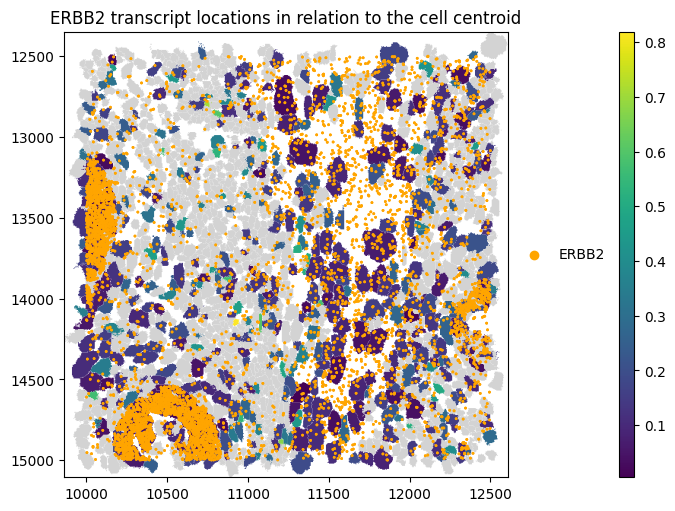

In [11]:
st_proseg2.sdata.pl.render_shapes(
    "cell_boundaries",
    color="distance_to_cell_centroid_norm_ERBB2",
).pl.render_points(
    "transcripts",
    color="gene",
    groups=["ERBB2"],
    palette=["orange"],
).pl.show(
    title="ERBB2 transcript locations in relation to the cell centroid",
    coordinate_systems="global",
    figsize=(10, 5),
)

We can do the same for Xenium-segmented data.

In [12]:
_distance_to_centroid = st_xenium.ps.distance_to_centroid(genes="ERBB2", restrict_to_within_boundary=True)

WARNING  Found 562 NaN values in color data. These observations will be colored with the 'na_color'.               
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/p

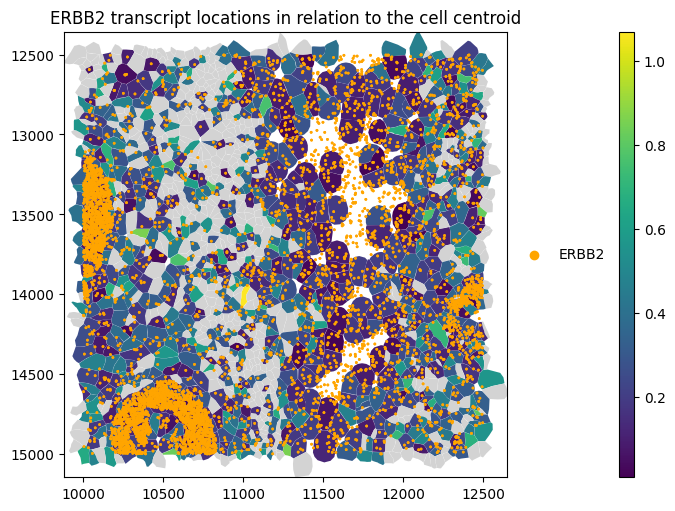

In [13]:
st_xenium.sdata.pl.render_shapes(
    "cell_boundaries",
    color="distance_to_cell_centroid_norm_ERBB2",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=["ERBB2"],
    palette=["orange"],
).pl.show(
    title="ERBB2 transcript locations in relation to the cell centroid",
    coordinate_systems="global",
    figsize=(10, 5),
)

When computing the distance across all transcripts (`genes=None`), the average `distance_all_genes` is close to zero, as the mean transcript position converges toward the cell centroid when many points are averaged.

We might also be interested in whether a gene's transcripts are further away from the cell than the nucleus centroid.

In [14]:
for _method, st in st_dict.items():
    st.ps.distance_to_centroid(centroid_region="nucleus", genes="ERBB2", restrict_to_within_boundary=True)

WARNING  Found 991 NaN values in color data. These observations will be colored with the 'na_color'.               
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/p

WARNING  Found 1100 NaN values in color data. These observations will be colored with the 'na_color'.              
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/p

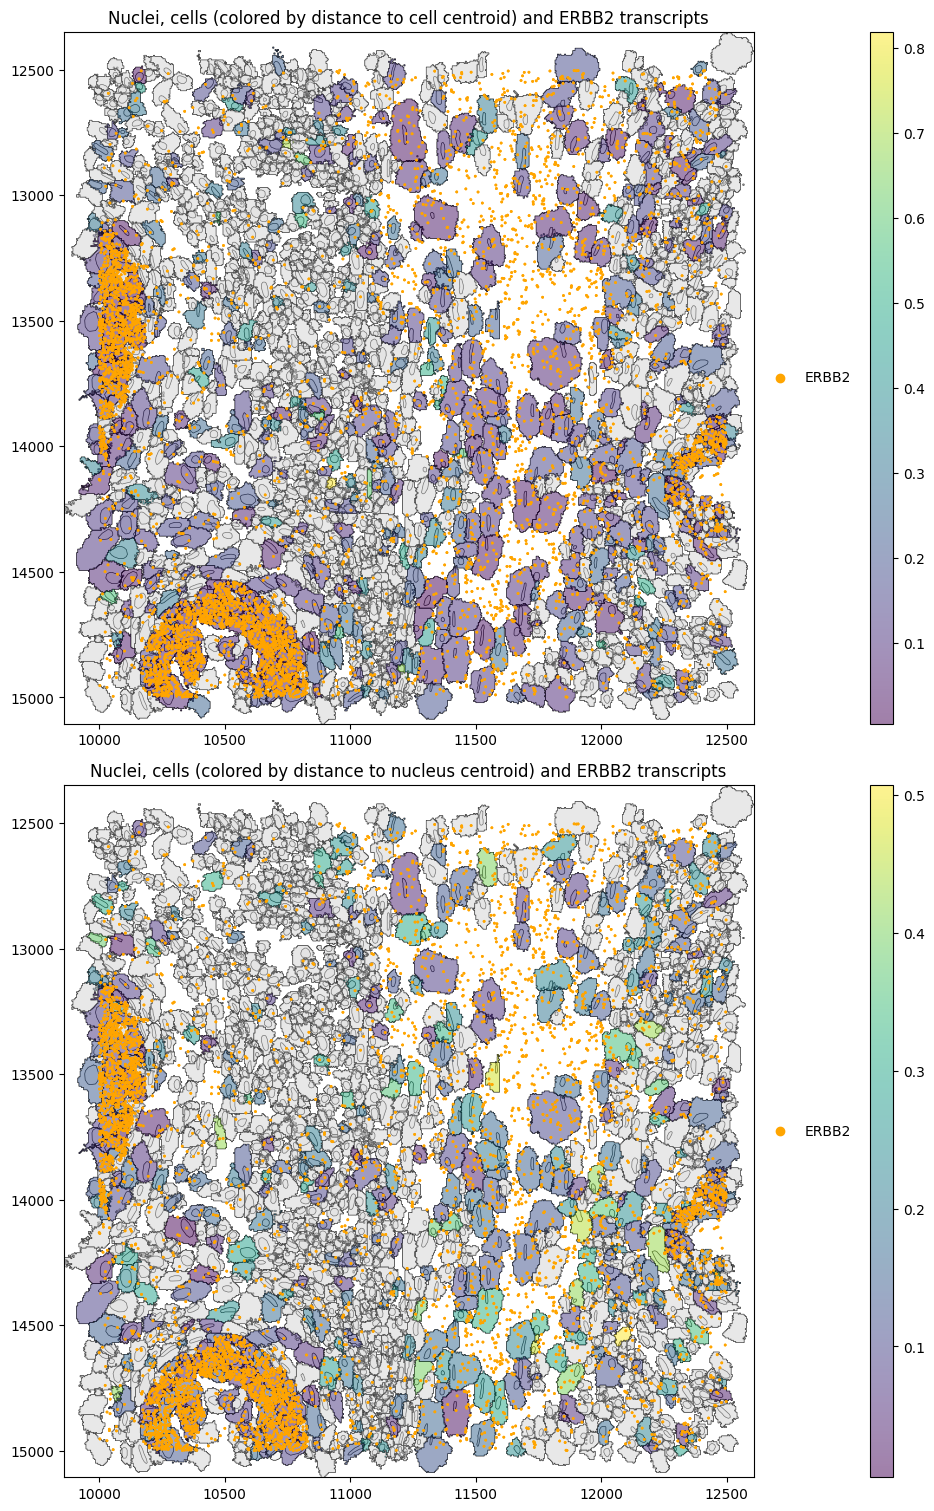

In [15]:
axes = plt.subplots(2, 1, figsize=(15, 15), constrained_layout=True)[1].flatten()

st_proseg2.sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="distance_to_cell_centroid_norm_ERBB2",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_points(
    "transcripts",
    color="gene",
    groups=["ERBB2"],
    palette=["orange"],
).pl.show(ax=axes[0], title="Nuclei, cells (colored by distance to cell centroid) and ERBB2 transcripts", colorbar=True)

st_proseg2.sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="distance_to_nucleus_centroid_norm_ERBB2",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_points(
    "transcripts",
    color="gene",
    groups=["ERBB2"],
    palette=["orange"],
).pl.show(
    ax=axes[1], title="Nuclei, cells (colored by distance to nucleus centroid) and ERBB2 transcripts", colorbar=True
)

## Distance to membrane

Another way to look at the spatial distribution of transcripts is the distance of a gene's transcripts to the boundary (membrane). In some sense, this is complementary to the `distance_to_centroid` metric. However, in the case of very irregularly shaped cells, the distance to the membrane is a more direct measure of unequal transcript distribution and hence potential spillover.  

For each transcript, we compute its distance to the selected boundary, defined either by the cell outline or by a matched nucleus. Distances can be treated as signed (positive inside/on the boundary, negative outside), setting `signed=True`, and the computation can optionally be restricted to transcripts that lie within the selected boundary (`restrict_to_within_boundary=True`). 

The per-cell metric is defined as the mean distance to the cell/nuclear membrane $\mu(d(m,t))$ (as provided in the `spatialdata` object) divided by boundary-specific length-scale $\sqrt{|B|}$.
Again, this can be applied either to specific genes or all genes simultaneously.

$$
d_{membrane} = \frac{\mu(d(m,t))}{\sqrt{|B|}}
$$

Let's investigate the distance of MS4A1 (a B-cell marker) in B cells. Below it looks like MS4A1 is mostly expressed in the nucleus.

In [16]:
for _method, st in st_dict.items():
    st.ps.distance_to_membrane(genes="MS4A1", cell_type_query="B", restrict_to_within_boundary=True)

WARNING  Found 1537 NaN values in color data. These observations will be colored with the 'na_color'.              
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/p

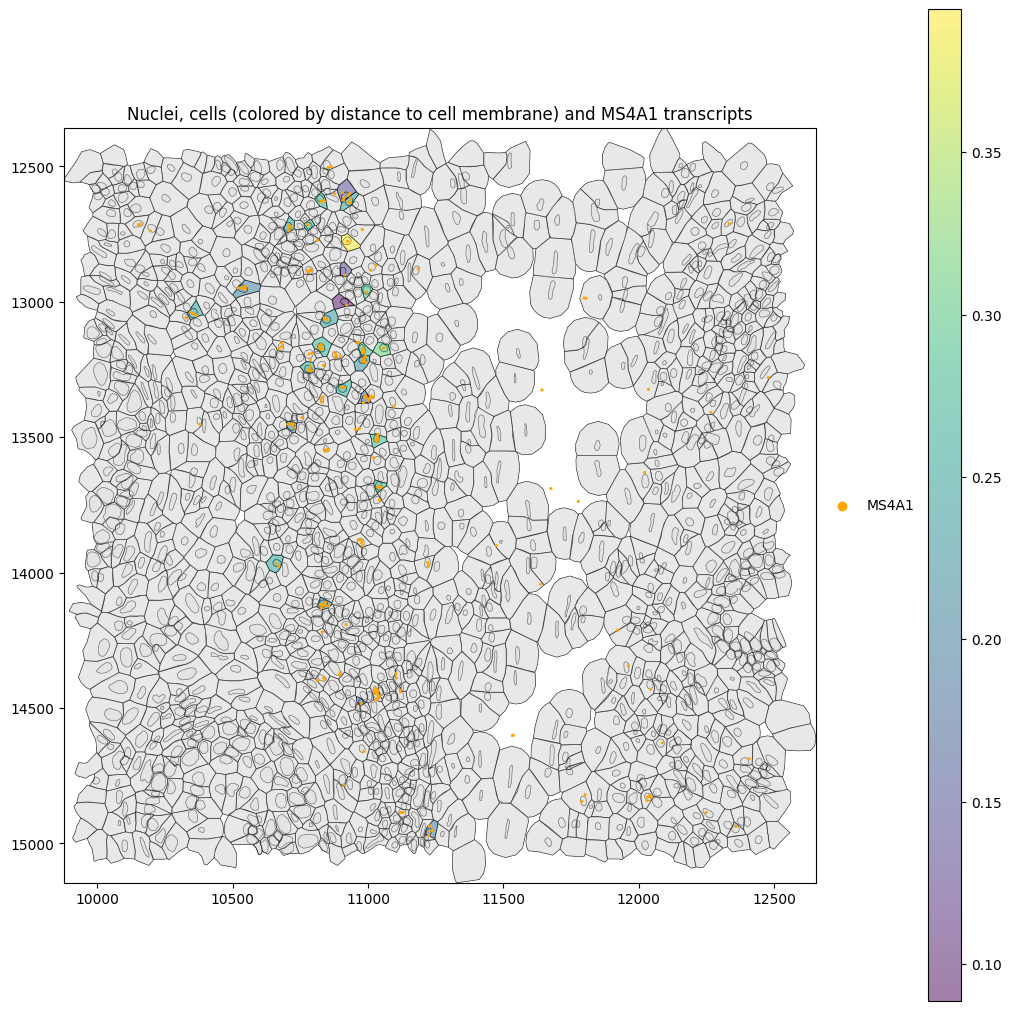

In [17]:
st_xenium.sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="distance_to_cell_membrane_norm_MS4A1",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=["MS4A1"],
    palette=["orange"],
).pl.show(
    figsize=(10, 10), title="Nuclei, cells (colored by distance to cell membrane) and MS4A1 transcripts", colorbar=True
)

Let's compute the mean distance to the nucleus and cell membrane to verify this. This confirms that MS4A1 transcripts are located closer to the nuclear than to the cell membrane. 

In [18]:
for _method, st in st_dict.items():
    st.ps.distance_to_membrane(
        genes="MS4A1", cell_type_query="B", membrane_region="nucleus", restrict_to_within_boundary=True
    )

In [19]:
xenium_cell_membrane = st_xenium.sdata.tables["table"].obs["distance_to_cell_membrane_norm_MS4A1"].mean()
xenium_nucleus_membrane = st_xenium.sdata.tables["table"].obs["distance_to_nucleus_membrane_norm_MS4A1"].mean()

print("Xenium:")
print(f"Mean distance of MS4A1 transcripts to cell membrane: {xenium_cell_membrane}.")
print(f"Mean distance of MS4A1 transcripts to nucleus membrane: {xenium_nucleus_membrane}.")

Xenium:
Mean distance of MS4A1 transcripts to cell membrane: 0.2337680414403614.
Mean distance of MS4A1 transcripts to nucleus membrane: 0.10078348677121293.


In [20]:
proseg_cell_membrane = st_proseg2.sdata.tables["table"].obs["distance_to_cell_membrane_norm_MS4A1"].mean()
proseg_nucleus_membrane = st_proseg2.sdata.tables["table"].obs["distance_to_nucleus_membrane_norm_MS4A1"].mean()

print("Xenium:")
print(f"Mean distance of MS4A1 transcripts to cell membrane: {proseg_cell_membrane}.")
print(f"Mean distance of MS4A1 transcripts to nucleus membrane: {proseg_nucleus_membrane}.")

Xenium:
Mean distance of MS4A1 transcripts to cell membrane: 0.07180125104927072.
Mean distance of MS4A1 transcripts to nucleus membrane: 0.044817586706642924.


## Percentage of points in compartments

To determine the percentage of transcripts of a cell that localize to cell nulceus, the cell cytoplasm and those that are outside the cell membrane, we can provide the `percentage_points_compartments` function. 

In [21]:
gene = "MS4A1"
celltype = "B"
for _method, st in st_dict.items():
    st.ps.percentage_transcripts_in_compartments(genes=gene, cell_type_query=celltype)

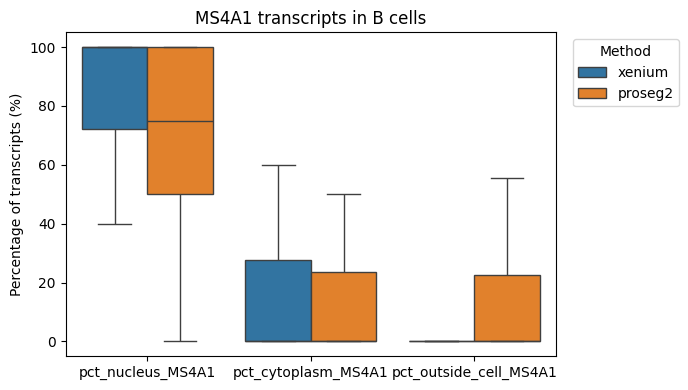

In [22]:
rows = []

for method, st in st_dict.items():
    obs = st.sdata.tables["table"].obs

    df = obs[[f"pct_nucleus_{gene}", f"pct_cytoplasm_{gene}", f"pct_outside_cell_{gene}"]].copy()

    df["method"] = method
    rows.append(df)

df_all = pd.concat(rows, axis=0, ignore_index=True)

df_long = df_all.melt(
    id_vars=["method"],
    value_vars=[f"pct_nucleus_{gene}", f"pct_cytoplasm_{gene}", f"pct_outside_cell_{gene}"],
    var_name="compartment",
    value_name="percentage",
)

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_long,
    x="compartment",
    y="percentage",
    hue="method",
    showfliers=False,  # usually nicer for percentages
)

plt.ylabel("Percentage of transcripts (%)")
plt.xlabel("")
plt.title(f"{gene} transcripts in {celltype} cells")

plt.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

We might be interested in the distribution of transcripts of gene "ERBB2" (a DCIS2 marker) in all cell types. 

In [23]:
for _method, st in st_dict.items():
    st.ps.percentage_transcripts_in_compartments(genes="ERBB2")

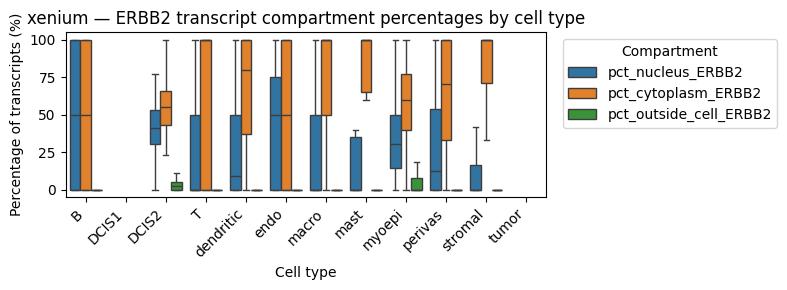

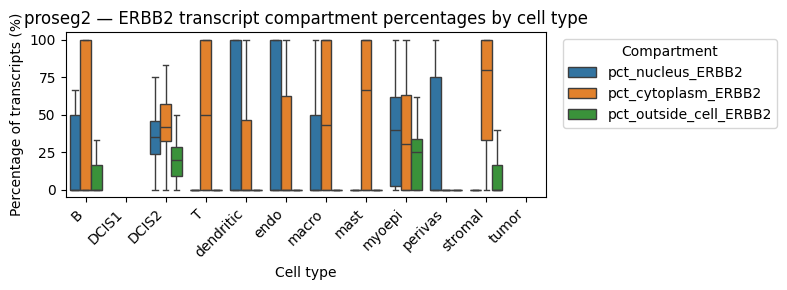

In [24]:
gene = "ERBB2"
cell_type_key = "transferred_cell_type"
tables_key = "table"

for method, st in st_dict.items():
    obs = st.sdata.tables[tables_key].obs

    df = obs[[cell_type_key, f"pct_nucleus_{gene}", f"pct_cytoplasm_{gene}", f"pct_outside_cell_{gene}"]].copy()
    df = df.dropna(subset=[cell_type_key])

    df_long = df.melt(
        id_vars=[cell_type_key],
        value_vars=[f"pct_nucleus_{gene}", f"pct_cytoplasm_{gene}", f"pct_outside_cell_{gene}"],
        var_name="compartment",
        value_name="percentage",
    )

    plt.figure(figsize=(8, 3))
    ax = sns.boxplot(
        data=df_long,
        x=cell_type_key,
        y="percentage",
        hue="compartment",
        showfliers=False,
    )

    ax.set_title(f"{method} — {gene} transcript compartment percentages by cell type")
    ax.set_xlabel("Cell type")
    ax.set_ylabel("Percentage of transcripts (%)")

    # rotate x labels if many cell types
    plt.xticks(rotation=45, ha="right")

    # put legend outside
    plt.legend(title="Compartment", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

These results show that ERBB2 transcripts are present at comparable percentages in the cytoplasm and nucleus of DCIS2 cells, whereas in all other cell types they are predominantly cytoplasmic (suggesting contamination). Notably, ERBB2 transcripts are also enriched in the nuclear compartment of myoepithelial cells, which frequently border DCIS2 cells. This likely reflects neighborhood contamination rather than myoepithelial expression. Also stromal cells show a high cytoplasmic expression of ERBB2. As expected, Proseg shows a higher fraction of transcripts outside the cell, consistent with its transcript repositioning mechanism.

Let's visualize this spatially.

In [25]:
# Define color palette for plotting
col_celltype = {
    "T": "#fb8072",
    "B": "#bc80bd",
    "macro": "#910290",
    "dendritic": "#fdb462",
    "mast": "#959059",
    "perivas": "#fed9a6",
    "endo": "#a6cee3",
    "myoepi": "#2782bb",
    "DCIS1": "#3c7761",
    "DCIS2": "#66a61e",
    "tumor": "#66c2a5",
    "stromal": "#d45943",
    "nan": "#808080",
}


def plot_feature_labels(sdata, method, feature, axes, i):
    labels = sdata.tables["table"].obs["transferred_cell_type"].unique().astype(str).tolist()
    cols = [col_celltype[lab] for lab in labels]

    sdata.tables["table"].obs["region"] = "cell_boundaries"
    sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

    sdata.pl.render_shapes(
        "cell_boundaries",
        color="transferred_cell_type",
        palette=cols,
        groups=labels,
        outline_color="white",
        outline_width=0.5,
    ).pl.show(ax=axes[0, i], title=f"{method}:Cell boundaries colored by cell type", coordinate_systems="global")

    sdata.pl.render_shapes(
        element="nucleus_boundaries",
        fill_alpha=0.2,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.render_shapes(
        element="cell_boundaries",
        color=feature,
        cmap="viridis",
        fill_alpha=0.5,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.render_points(
        "transcripts",
        color=st.points_gene_key,
        groups=["ERBB2"],
        palette=["orange"],
    ).pl.show(ax=axes[1, i], title=f"{method}: {feature}", coordinate_systems="global")

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:477: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


WARNING  Found 538 NaN values in color data. These observations will be colored with the 'na_color'.               
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/p

WARNING  Found 991 NaN values in color data. These observations will be colored with the 'na_color'.               
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/p

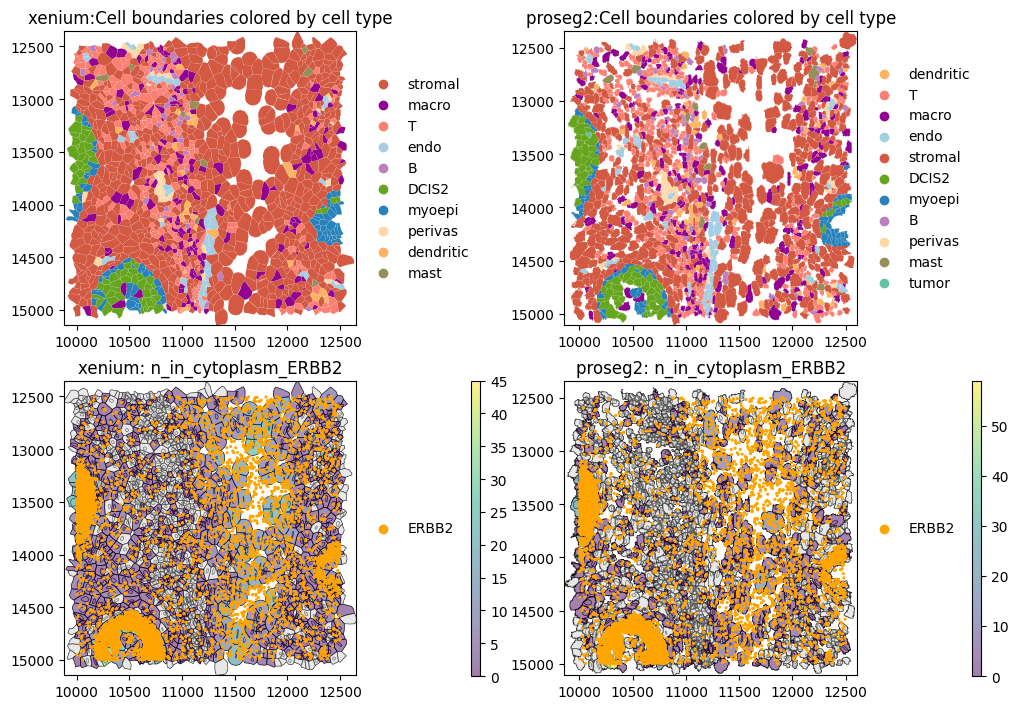

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
axes = np.atleast_2d(axes)
for i, (method, st) in enumerate(st_dict.items()):
    plot_feature_labels(st.sdata, method, "n_in_cytoplasm_ERBB2", axes, i)

The plots above show high ERBB2 transcript abundance in DCIS2 and myoepithelial cells, as well as high levels in stromal cells, where ERBB2 transcripts are largely excluded from the nuclear compartment.

## Membrane distance skewness

Membrane distance skewness quantifies the asymmetry of transcript distances to the cell boundary within individual cells, using only transcripts assigned to a cell and located inside or on its segmentation polygon. Positive skewness indicates an enrichment of transcripts close to the membrane, whereas negative skewness reflects a bias toward the cell interior. The metric is computed using Fisher–Pearson sample skewness and is reported only for cells with at least a minimum number of transcripts (`min_transcripts`) to ensure robust skewness estimates.

Let's evaluate the skewness of ERBB2 transcripts within cells. The `min_transcripts` set to 5 will exclude a lot of cells. 

In [27]:
_skew = st_proseg2.ps.membrane_distance_skewness(["ERBB2"], min_transcripts=5)

WARNING  Found 1440 NaN values in color data. These observations will be colored with the 'na_color'.              
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/meyerben/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/p

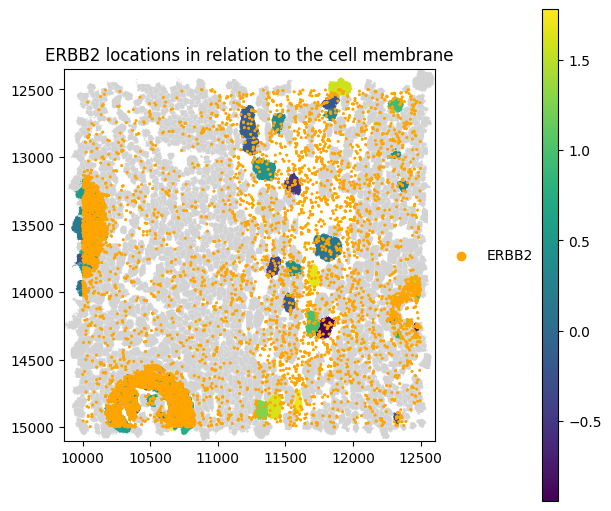

In [28]:
st_proseg2.sdata.pl.render_shapes(
    "cell_boundaries",
    color="skew_dist_to_cell_membrane_ERBB2",
).pl.render_points(
    "transcripts",
    color="gene",
    groups="ERBB2",
    palette="orange",
).pl.show(
    title="ERBB2 locations in relation to the cell membrane",
    coordinate_systems="global",
    figsize=(6, 5),
)

Let's evaluate the membrane distance skewness across all genes and plot the results in per-cell type boxplots.

In [29]:
for _method, st in st_dict.items():
    st.ps.membrane_distance_skewness(min_transcripts=5)

In [30]:
def boxplot_per_celltype(st_dict, feature, q=1):
    dfs = []
    for method, st in st_dict.items():
        obs = st.sdata["table"].obs[st.sdata["table"].obs["transferred_cell_type"].notna()].copy()
        obs["transferred_cell_type"] = obs["transferred_cell_type"].cat.remove_unused_categories()
        tmp = obs[["transferred_cell_type", feature]].copy()
        tmp["method"] = method
        dfs.append(tmp)

    df = pd.concat(dfs, ignore_index=True)
    df = df[(df[feature] <= df[feature].quantile(q))]

    fig, ax = plt.subplots(figsize=(15, 5))

    sns.boxplot(
        data=df,
        x="transferred_cell_type",
        y=feature,
        hue="method",
        showcaps=True,
        showfliers=False,
        palette="Set2",
        ax=ax,
    )

    fig.tight_layout()
    plt.show()

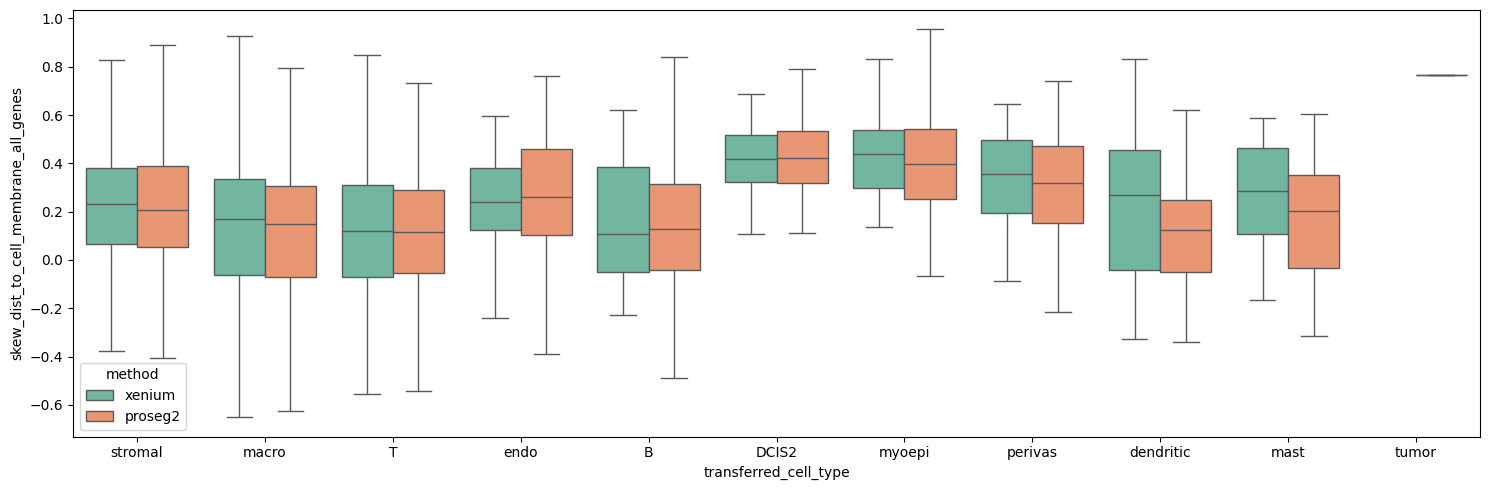

In [31]:
boxplot_per_celltype(st_dict, "skew_dist_to_cell_membrane_all_genes")

This shows the the transcripts are slightly more enriched close to the membrane for xenium, however, the differences are minor.

## Session Info

In [32]:
print(sd.__version__)  # spatialdata
print(spatialdata_plot.__version__)

0.7.2
0.2.13
